In [7]:
# list subjects
from labdata.schema import (
    Subject,
    SpikeSorting,
    Dataset,
    Session,
    UnitCount,
    UnitMetrics,
)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import textwrap
from diptest import diptest

%matplotlib widget

In [2]:
def analyze_unit(
    arr, i, n_chunks=5, bins=50, print_fig="False", print_stats="False", unit_id=None
):

    arr = np.asarray(arr)

    if len(arr) < n_chunks:
        print(f"Unit {i} too short")
        return None

    # =========================
    # Split into equal spike-count epochs
    # =========================
    chunks = np.array_split(arr, n_chunks)

    # =========================
    # Plot distributions
    # =========================
    if print_fig == "True":
        plt.figure()

        for j, chunk in enumerate(chunks):
            plt.hist(
                chunk, bins=bins, histtype="step", alpha=0.8, label=f"Chunk {j + 1}"
            )

        plt.title(f"Unit {unit_id}")
        plt.xlabel("Spike amplitude")
        plt.ylabel("Count")
        plt.legend()

    # =========================
    # Drift metric
    # =========================
    means = np.array([np.mean(chunk) for chunk in chunks])
    drift = (means.max() - means.min()) / means.mean()

    # =========================
    # Dip test (multimodality)
    # =========================
    dip_stats = []
    dip_pvals = []

    for chunk in chunks:
        results = diptest(chunk)
        dip = results[0]
        p = results[1]
        dip_stats.append(dip)
        dip_pvals.append(p)

    mean_dip = np.mean(dip_stats)
    mean_dip_p = np.mean(dip_pvals)

    # =========================
    # KS between chunks
    # =========================
    # ks_vals = []

    # for j in range(len(chunks) - 1):
    #     ks_stat, _ = ks_2samp(chunks[j], chunks[j+1])
    #     ks_vals.append(ks_stat)

    # mean_ks_between = np.mean(ks_vals) if len(ks_vals) > 0 else np.nan
    if print_stats == "True":
        print(f"unit id = {unit_id}")
        print(f"Drift = {drift:.3f}")
        print(f"Mean Dip = {mean_dip:.4f}")
        print(f"Mean Dip p = {mean_dip_p:.4g}")
        # print(f"KS between chunks = {mean_ks_between:.4f}")

    return {
        "drift": drift,
        "mean_dip": mean_dip,
        "mean_dip_p": mean_dip_p,
        "chunks": chunks,
        # "ks_between": mean_ks_between,
    }

In [ ]:
sessions = ((Subject() & 'subject_name = "GRB058"').proj() * SpikeSorting()).fetch(
    "session_name"
)

In [3]:
GRB058_session = ["20260224_152424"]
# MM012_sessions =  ['20231211_172819', '20231212_174741', '20231213_181147', '20231215_140148', '20231218_170114', '20231219_130847', '20231220_133116', '20231221_134112', '20231222_145357', '20231225_123125', '20231226_123754', '20231227_124152', '20231228_124820', '20231229_122644', '20240102_134855', '20240103_132955']
# 'MM013': ['20231211_181754', '20231212_183852', '20231213_185553', '20231215_150606', '20231218_175023', '20231219_135245', '20231220_142345', '20231221_142857', '20231222_141517', '20231225_130825', '20231226_114620', '20231227_132538', '20231228_121007', '20231229_131000', '20240102_131102', '20240103_141448']

In [ ]:
imec0_change_in_unit_counts = []
##MM012 spike sorting to evaluate spike stability
for s in range(len(GRB058_session)):
    this_session = GRB058_session[s]
    session = f'session_name = "{this_session}"'

    animal_session = (SpikeSorting & 'subject_name = "GRB058"') & session
    spikesortingprobes = (animal_session).proj().fetch(as_dict=True)

    sessions = Session & (SpikeSorting() & dict(subject_name="GRB058"))
    specific_session = (Dataset & sessions & session).proj().fetch(as_dict=True)
    selected_session = (Session & specific_session[1]).fetch1()

    UnitCount().populate(processes=10, display_progress=True)

    sua = (
        UnitMetrics()
        & session
        & "isi_contamination < 0.1"
        & "amplitude_cutoff < 0.1"
        & "spike_duration > 0.1"
        & "spike_amplitude > 50"
        & "presence_ratio > 0.6"
        & "firing_rate > 1"
    )
    sua_depth_stability = sua & "depth_drift_start_to_end < 6"

    units = pd.DataFrame((SpikeSorting.Unit * UnitMetrics & spikesortingprobes).fetch())
    imec0_units = pd.DataFrame(
        (SpikeSorting.Unit * UnitMetrics & spikesortingprobes[0]).fetch()
    )

    ks4_single_units = pd.DataFrame(sua)
    ks4_drift_single_units = pd.DataFrame(sua_depth_stability)
    imec0_single_units = pd.DataFrame(sua_depth_stability & "probe_num = 0")

    imec0_single_units_before_drift_metric = pd.DataFrame(sua & "probe_num = 0")

    units = [imec0_units]
    single_units = [imec0_single_units]

    all_probe_analysis = []

    for i in range(1):
        all_cell_analysis = []
        matching_indices = np.where(np.isin(units[i].unit_id, single_units[i].unit_id))[
            0
        ]

        single_unit_spiking_info = units[i].iloc[matching_indices]
        # will need to loop through units

        for i in range(len(single_unit_spiking_info)):
            y = single_unit_spiking_info.spike_amplitudes.iloc[i]
            x = single_unit_spiking_info.spike_times.iloc[i]
            cell_analysis = analyze_unit(
                y, i, n_chunks=5, bins=50, print_fig="False", print_stats="False"
            )
            all_cell_analysis.append(cell_analysis)
        all_probe_analysis.append(all_cell_analysis)
    imec0_df = pd.DataFrame(all_probe_analysis[0])

    imec0_high_amp_drift_cells = imec0_df.index[imec0_df["drift"] > 0.10].tolist()
    imec0_high_bimodal_cells = imec0_df.index[imec0_df["mean_dip_p"] < 0.6].tolist()
    imec0_ks4_drift_and_amp_drift_single_units = len(single_units[0]) - len(
        imec0_high_bimodal_cells
    )
    imec0_high_amp_not_high_bimodal = list(
        set(imec0_high_amp_drift_cells) - set(imec0_high_bimodal_cells)
    )
    imec0_ks4_drift_and_amp_drift_and_unimodal_single_units = (
        imec0_ks4_drift_and_amp_drift_single_units
        - len(imec0_high_amp_not_high_bimodal)
    )

    imec0_change_in_unit_count = [
        len(imec0_single_units_before_drift_metric),
        len(single_units[0]),
        imec0_ks4_drift_and_amp_drift_single_units,
        imec0_ks4_drift_and_amp_drift_and_unimodal_single_units,
    ]

    imec0_change_in_unit_counts.append(imec0_change_in_unit_count)

/var/folders/k4/_l1cqd4d0gn02n75d0rrj10h0000gr/T/ipykernel_33098/3407789187.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


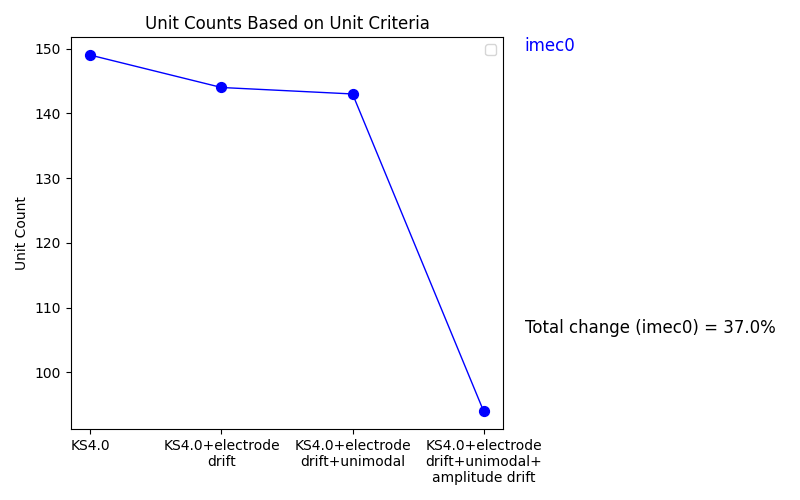

In [36]:
fig, ax = plt.subplots(figsize=(8, 5))
for i in range(len(imec0_change_in_unit_counts)):
    ax.plot(imec0_change_in_unit_counts[i], "b", linewidth=1)
#     plt.plot(imec1_change_in_unit_counts[i], 'r', linewidth = 1)
ax.scatter(
    [0, 1, 2, 3], [np.mean(imec0_change_in_unit_counts, axis=0)], s=50, color="blue"
)
# plt.scatter([0,1,2,3],[np.mean(imec1_change_in_unit_counts,axis=0)], s=50, color='red')
ax.set_title("Unit Counts Based on Unit Criteria")
ax.set_ylabel(("Unit Count"))
tick_positions = [0, 1, 2, 3]
long_labels = [
    "KS4.0",
    "KS4.0+electrode drift",
    "KS4.0+electrode drift+unimodal",
    "KS4.0+electrode drift+unimodal+amplitude drift",
]
max_width = 15  # Set the maximum width for each line
wrapped_labels = [textwrap.fill(label, max_width) for label in long_labels]
ax.set_xticks(tick_positions, wrapped_labels)
ax.legend()
ax.text(
    1.05,
    0.28,
    f"Total change (imec0) = {round((imec0_change_in_unit_counts[0][0] - imec0_change_in_unit_counts[0][-1]) / imec0_change_in_unit_counts[0][0], 2) * 100}%",
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment="top",
)
# ax.text(1.05, 0.52, 'Total change (imec1) = 8%',
#         transform=ax.transAxes,
#         fontsize=12,
#         verticalalignment='top')

ax.text(
    1.05,
    1.0,
    "imec0",
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment="top",
    color="b",
)
# ax.text(1.05, 0.9, 'imec1',
#         transform=ax.transAxes,
#         fontsize=12,
#         verticalalignment='top',
#         color='r')

fig.tight_layout()

In [ ]:
# will need to loop through probes
# imec0_single_units.unit_id
# imec0_units.unit_id
units = [imec0_units]  # , imec1_units]
single_units = [imec0_single_units]  # ,imec1_single_units]

all_probe_analysis = []

for i in range(1):
    all_cell_analysis = []
    matching_indices = np.where(np.isin(units[i].unit_id, single_units[i].unit_id))[0]

    single_unit_spiking_info = units[i].iloc[matching_indices]
    # will need to loop through units

    for i in range(len(single_unit_spiking_info)):
        y = single_unit_spiking_info.spike_amplitudes.iloc[i]
        x = single_unit_spiking_info.spike_times.iloc[i]
        unit_id = single_unit_spiking_info.unit_id.values[i]
        cell_analysis = analyze_unit(
            y,
            i,
            n_chunks=5,
            bins=50,
            print_fig="True",
            print_stats="True",
            unit_id=unit_id,
        )
        all_cell_analysis.append(cell_analysis)
    all_probe_analysis.append(all_cell_analysis)
imec0_df = pd.DataFrame(all_probe_analysis[0])
# imec1_df = pd.DataFrame(all_probe_analysis[1])

imec0_high_amp_drift_cells = imec0_df.index[imec0_df["drift"] > 0.10].tolist()
# imec1_high_amp_drift_cells = imec1_df.index[imec1_df["drift"] > 0.10].tolist()
# print("Cell indices with drift > 0.1:", high_amp_drift_cells)
imec0_high_bimodal_cells = imec0_df.index[imec0_df["mean_dip_p"] < 0.6].tolist()
# imec1_high_bimodal_cells = imec1_df.index[imec1_df["mean_dip_p"] < 0.6].tolist()
# print("Cell indices with dip_p < 0.6:", high_bimodal_cells)
# print("KS4.0 'good' + electrode drift = ", len(ks4_drift_single_units))
# print("KS4.0 'good' cells = ", len(ks4_single_units))
imec0_ks4_drift_and_amp_drift_single_units = len(single_units[0]) - len(
    imec0_high_bimodal_cells
)
imec0_high_amp_not_high_bimodal = list(
    set(imec0_high_amp_drift_cells) - set(imec0_high_bimodal_cells)
)
imec0_ks4_drift_and_amp_drift_and_unimodal_single_units = (
    imec0_ks4_drift_and_amp_drift_single_units - len(imec0_high_amp_not_high_bimodal)
)

# imec1_ks4_drift_and_amp_drift_single_units = len(single_units[1])-len(imec1_high_bimodal_cells)
# imec1_high_amp_not_high_bimodal = list(set(imec1_high_amp_drift_cells) - set(imec1_high_bimodal_cells))
# imec1_ks4_drift_and_amp_drift_and_unimodal_single_units = imec1_ks4_drift_and_amp_drift_single_units - len(imec1_high_amp_not_high_bimodal)

imec0_change_in_unit_count = [
    len(imec0_single_units_before_drift_metric),
    len(single_units[0]),
    imec0_ks4_drift_and_amp_drift_single_units,
    imec0_ks4_drift_and_amp_drift_and_unimodal_single_units,
]
# imec1_change_in_unit_count = [len(imec1_single_units_before_drift_metric),len(single_units[1]), imec1_ks4_drift_and_amp_drift_single_units, imec1_ks4_drift_and_amp_drift_and_unimodal_single_units]

# imec0_change_in_unit_count, imec1_change_in_unit_count


imec0_change_in_unit_counts.append(imec0_change_in_unit_count)
# imec1_change_in_unit_counts.append(imec1_change_in_unit_count)